# KNN in sklearn

K-nearest neighbors, or KNN for short, is one of the simplest machine learning algorithms and is used in a wide array of institutions. 

In this notebook we will have a look at how you can train a k-nearest neighbor model using the sklearn library. We will use the breast cancer data set, which is also a "toy" data set provided by `sklearn.datasets`.

At the end of the notebook you should know:
* how to apply KNN with sklearn
* what hyperparameter you can tweak in the knn model (only the most important)

## Setup and Data

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

## The Algorithm 

KNN is a non-parametric, lazy learning algorithm. When we say a technique is non-parametric, it means that it does not make any assumptions about the underlying data. In other words, it makes its selection based off of the proximity to other data points regardless of what feature the numerical values represent. Being a lazy learning algorithm implies that there is little to no training phase. Therefore, we can immediately classify new data points as they present themselves.

Some **pros** and **cons** of KNN:

#### Pros

* No assumptions about data
* Simple algorithm: easy to understand
* Can be used for classification and regression


#### Cons

* High memory requirement: all of the training data must be present in memory in order to calculate the closest K neighbors
* Sensitive to irrelevant features
* Sensitive to the scale of the data since we’re computing the distance to the closest K points

## Example

Let’s take a look at how we could go about classifying data using the K-nearest neighbors algorithm in Python. 

For this tutorial, we’ll be using the breast cancer dataset from the `sklearn.datasets` module. The dataset classifies tumors into two categories (malignant and benign) and contains about 30 features. In the real world, you’d look at the correlations and select a subset of features that plays the greatest role in determining whether a tumor is malignant or not. However, for the sake of simplicity, we’ll pick a couple at random (Feel free to have a look at the data, print the correlations and choose the most appropriate features). 
If you choose a categorical feature it needs to be encoded to be interpreted by the model.

In [2]:
# Load data
breast_cancer = load_breast_cancer()

# Define two features randomly
X = pd.DataFrame(breast_cancer.data, columns=breast_cancer.feature_names)
X = X[["mean area", "mean compactness"]]
X.head(2)

,mean area,mean compactness
0,1001.0,0.27760
1,1326.0,0.07864


In [6]:
full_df = pd.DataFrame(breast_cancer.data, columns=breast_cancer.feature_names)
pd.set_option('display.max_columns', None)   # show all columns, not "..."
print(full_df.shape)
full_df.head()

(569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## شرح أعمدة مجموعة بيانات سرطان الثدي

البيانات مأخوذة من صور مجهرية لخلايا الورم. هناك **10 قياسات**، وكل قياس موجود في **3 نسخ**:

| المجموعة | الأعمدة | المعنى |
|---|---|---|
| `mean ...` | 1–10 | **المتوسط**: متوسط القيمة لكل الخلايا في الصورة |
| `... error` | 11–20 | **الخطأ المعياري**: مدى تغيّر القيمة بين الخلايا |
| `worst ...` | 21–30 | **الأسوأ**: أكبر قيمة (أسوأ حالة) وُجدت في الصورة |

### معنى القياسات العشرة

| الاسم | المعنى |
|---|---|
| **radius** | نصف القطر: متوسط المسافة من مركز الخلية إلى حدودها |
| **texture** | الملمس: مدى تفاوت درجات اللون الرمادي في الصورة |
| **perimeter** | المحيط: طول حدود الخلية |
| **area** | المساحة: حجم الخلية |
| **smoothness** | النعومة: مدى انتظام حدود الخلية |
| **compactness** | الانضغاط: المحيط² ÷ المساحة − 1، ويقيس مدى قرب الشكل من الدائرة |
| **concavity** | التقعّر: عمق الأجزاء المقعّرة في حدود الخلية |
| **concave points** | النقاط المقعّرة: عدد الأجزاء المقعّرة في الحدود |
| **symmetry** | التماثل: مدى تماثل شكل الخلية |
| **fractal dimension** | البُعد الكسري: مدى تعقيد وتعرّج الحدود |

### مثال
- `mean area`: متوسط مساحة الخلايا
- `area error`: مقدار اختلاف المساحة بين الخلايا
- `worst area`: أكبر مساحة وُجدت

### ملاحظة
الخلايا **الخبيثة** تكون عادةً أكبر حجماً (`radius`، `area`، `perimeter`) وحدودها غير منتظمة أكثر (`concavity`، `concave points`).

**الهدف (target):** `0` = خبيث (malignant)، `1` = حميد (benign)

In [7]:
# Target variable
print(breast_cancer.target_names)
breast_cancer.target[:30]

['malignant' 'benign']


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0])

Right now our target variable is stored as 0 (for malignant) and 1 (for benign). We could replace it with the target names, but since the confusion matrix will (as default) show 0 and 1 as class labels, we will stick to the encoded version. Since our aim is to predict malignant tumors and usually the class we are interested in is encoded as class 1, we will flip the values for malignant and benign. 

In [8]:
# Flip labels so malignant is represented by 1.
y = pd.Series(breast_cancer.target, name="target").replace({0: 1, 1: 0}).to_frame()

In [9]:
# Split data into train and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

The sklearn library has provided a layer of abstraction on top of Python. 
Therefore, in order to make use of the KNN algorithm, it’s sufficient to create an instance of `KNeighborsClassifier`. 
By default, the KNeighborsClassifier looks for the 5 nearest neighbors. 
We must explicitly tell the classifier to use Euclidean distance for determining the proximity between neighboring points.

In [10]:
# Train model
knn = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
knn.fit(X_train, np.ravel(y_train))

,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


Accuracy: 0.85
Recall: 0.76
--------------------------------------------------


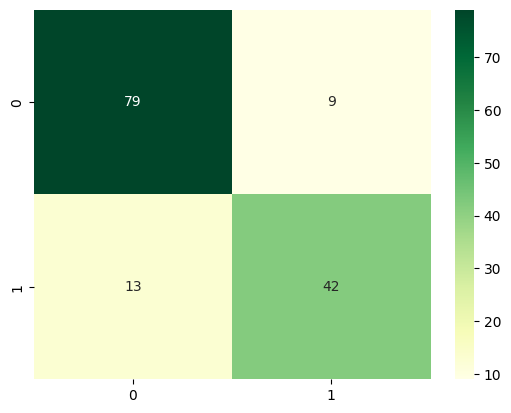

In [11]:
# Predict on test set
y_pred = knn.predict(X_test)

# Print accuracy score
print("Accuracy:", round(accuracy_score(y_test, y_pred), 2))
print("Recall:", round(recall_score(y_test, y_pred), 2))
print("-----" * 10)

# Print confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="YlGn");

## Check your understanding:

- What hyperparameter can you change in order to improve (or deteriorate) your model? 

<details>
<summary>Show answer</summary>

The main one is `n_neighbors` (the k in KNN): how many nearest neighbors get to vote on a point's label. A small k makes the model sensitive to noise and can overfit, while a large k smooths the decision boundary and can underfit, so it is usually the first thing to tune. Other useful hyperparameters are `metric` (which distance to use, for example euclidean or manhattan) and `weights` (`uniform` counts every neighbor equally, `distance` gives closer neighbors more influence). This notebook builds the model with `n_neighbors=5` and `metric='euclidean'`, so those are the natural ones to start experimenting with.
</details>

- If you're not sure about the hyperparameter of the KNN model, have a look at the sklearn documentation.
- Tweak some of them to get a better feeling of what will change if you do so.

### الـ Hyperparameter في نموذج KNN

أهم **Hyperparameter** يمكن تغييره في نموذج KNN هو `n_neighbors`، وهو يمثل عدد أقرب الجيران الذين يشاركون في التصويت لتحديد فئة نقطة بيانات جديدة.

مثلاً:

```python
KNeighborsClassifier(n_neighbors=5)

### Hyperparameters أخرى في KNN

- `metric`: تحدد **طريقة حساب المسافة بين النقاط**، مثل:
  - `euclidean`: تحسب المسافة المباشرة بين نقطتين.
  - `manhattan`: تحسب المسافة من خلال مجموع الفروق المطلقة بين الخصائص.

- `weights`: تحدد **مدى تأثير كل جار على القرار**:
  - `uniform`: جميع الجيران لهم **نفس التأثير**، بغض النظر عن المسافة.
  - `distance`: الجيران **الأقرب لهم تأثير أكبر** من الجيران الأبعد.